# Project 2 — Fracture X-Ray Analysis

## Goal
Process and analyze fracture X-ray scans using classical computer vision
techniques to highlight fracture regions, detect bone boundaries, and isolate
structures of interest — simulating the preprocessing stage of a real medical
AI pipeline.

## Disease Description
A **bone fracture** is a break in the continuity of bone tissue. On X-ray
imaging, fractures appear as dark irregular lines cutting across the bright
white bone structure. Early and accurate detection of fractures is critical
in emergency radiology, as missed fractures can lead to serious complications.

## Techniques Applied
- Grayscale conversion
- Thresholding
- Morphological operations (opening & closing)
- Canny edge detection
- Contour detection and drawing

## Dataset
FracAtlas — Bone Fracture Multi-Region X-Ray Dataset 
Source: https://www.kaggle.com/datasets/mahmudulhasantasin/fracatlas-original-dataset
Regions: Hand, Wrist, Hip, Ankle
Format: JPG

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [7]:
img_1 = cv2.imread('Data/IMG0000025.jpg')
img_2 = cv2.imread('Data/IMG0000351.jpg')
img_3 = cv2.imread('Data/IMG0001351.jpg')
img_4 = cv2.imread('Data/IMG0001981.jpg')
img_5 = cv2.imread('Data/IMG0002340.jpg')

In [44]:
# plt.figure(figsize=(12,12))

# plt.subplot(321);plt.imshow(img_1,cmap='gray')
# plt.subplot(322);plt.imshow(img_2,cmap='gray')
# plt.subplot(323);plt.imshow(img_3,cmap='gray')
# plt.subplot(324);plt.imshow(img_4,cmap='gray')
# plt.subplot(325);plt.imshow(img_5,cmap='gray')

## Image 1 — Arm/Elbow (Large bone)

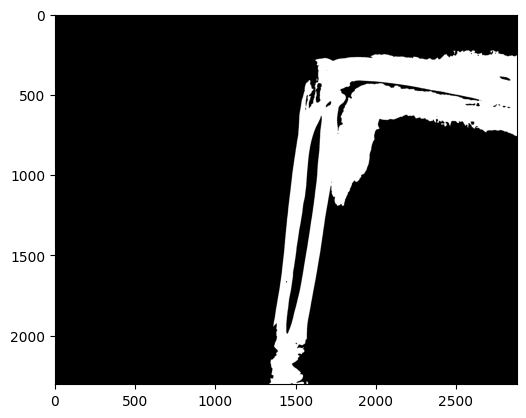

In [91]:
img_1 = cv2.imread('Data/IMG0000025.jpg')

## Convert to GrayScale
gray = cv2.imread('Data/IMG0000025.jpg',0)

## CLAHE for contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(20,20))
enhanced = clahe.apply(gray)

## Blur Image

blurred = cv2.GaussianBlur(enhanced,(21,21),0)

## Apply Thresholding

ret,thresh = cv2.threshold(blurred,110,255,cv2.THRESH_BINARY)
plt.imshow(thresh,cmap='gray')




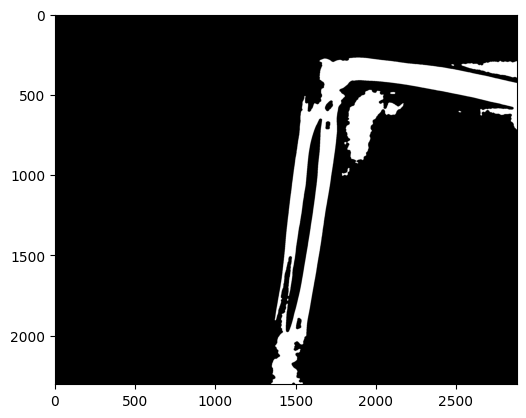

In [73]:
# Step 4: Morphological close — fill gaps in bone
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

plt.imshow(thresh,cmap='gray')

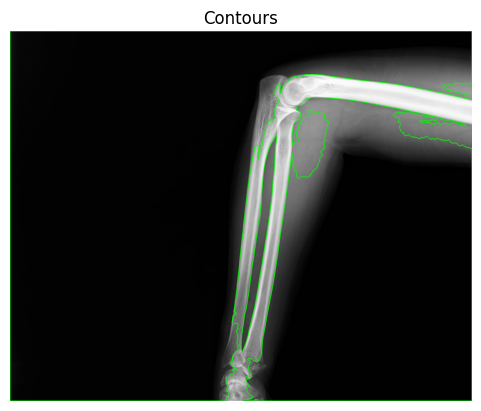

In [62]:
## Step 5: Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

## Step 6: Keep ONLY the largest contours (bones are large bright regions)
contours = sorted(contours, key=cv2.contourArea, reverse=True)
bone_contours = [c for c in contours if cv2.contourArea(c) > 1000]  # tune this

## Step 7: Draw on original
output = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(output, bone_contours, -1, (0, 255, 0), 3)

plt.title("Contours")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

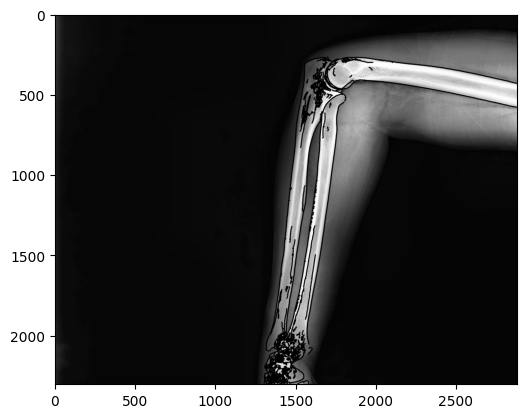

In [41]:
#Find Contours
copy = gray.copy()
contours, hierachy = cv2.findContours(canny, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(copy,contours, -1,(0,255,0),5)

plt.imshow(copy,cmap='gray');

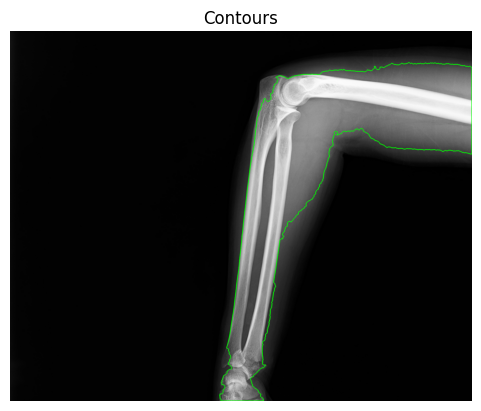

In [87]:
img_1 = cv2.imread('Data/IMG0000025.jpg')
gray = cv2.imread('Data/IMG0000025.jpg', 0)

## Step 1: CLAHE for contrast
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

## Step 2: Blur
blurred = cv2.GaussianBlur(enhanced, (5,5), 0)

## Step 3: Threshold — isolate BRIGHT bone only
ret, thresh = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY)

## Step 4: Morphological close — fill gaps in bone
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

## Step 5: Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

## Step 6: Keep ONLY the largest contours (bones are large bright regions)
contours = sorted(contours, key=cv2.contourArea, reverse=True)
bone_contours = [c for c in contours if cv2.contourArea(c) > 2000]  # tune this

## Step 7: Draw on original
output = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(output, bone_contours, -1, (0, 255, 0), 3)

plt.title("Contours")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

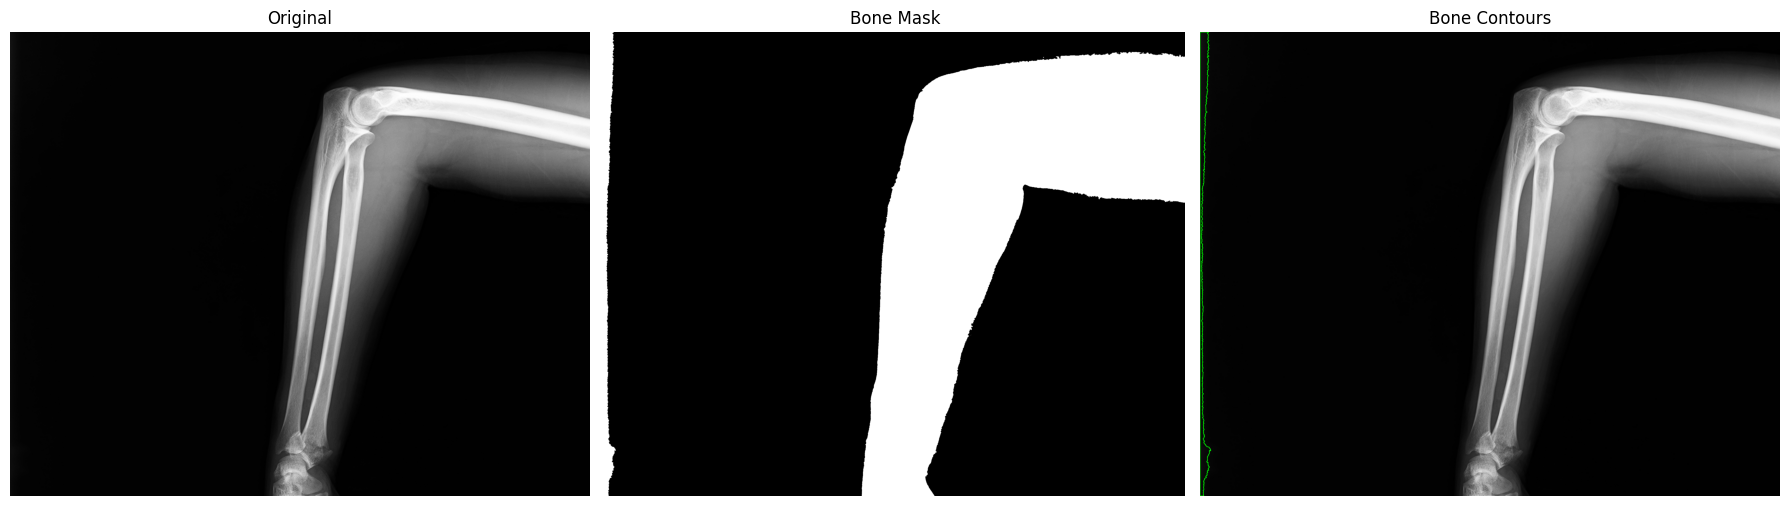

In [89]:
gray = cv2.imread('Data/IMG0000025.jpg', 0)

# ── 1. CLAHE + Blur
clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
eq     = clahe.apply(gray)
blur   = cv2.GaussianBlur(eq, (5, 5), 0)  # SMALL blur — don't merge bones

# ── 2. Percentile threshold — bright bone only
thresh_val = int(np.percentile(blur, 75))  # top 25% brightest = bone cortex
_, bright  = cv2.threshold(blur, thresh_val, 255, cv2.THRESH_BINARY)

# ── 3. Small close ONLY — just fill tiny holes, don't merge separate bones
k1     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
bright = cv2.morphologyEx(bright, cv2.MORPH_CLOSE, k1, iterations=2)

# ── 4. Remove noise — keep only bone-sized regions
contours, _ = cv2.findContours(bright, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

h_img, w_img = gray.shape
bone_contours = []
for c in contours:
    area = cv2.contourArea(c)
    # Bones are long and thin — filter by area and aspect ratio
    if area < 500:  # too small = noise
        continue
    x, y, w, h = cv2.boundingRect(c)
    aspect = max(w, h) / (min(w, h) + 1)
    if aspect < 2.0:  # bones are elongated, not square blobs
        continue
    bone_contours.append(c)

# ── 5. Draw each bone contour individually
output = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(output, bone_contours, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(gray,   cmap='gray'); axes[0].set_title('Original');      axes[0].axis('off')
axes[1].imshow(bright, cmap='gray'); axes[1].set_title('Bone Mask');     axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
axes[2].set_title('Bone Contours'); axes[2].axis('off')
plt.tight_layout()
plt.show()

## Image 2 — Wrist/Hand (Small bones)

## Image 3 — Foot (with toes)

## Image 4 — Foot (clean view)

## Image 5 — Pelvis/Hip (complex bone)